In [1]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

base_dir = Path(".").resolve()
c_index = 12
n_index = 0

candidate_xyz = [
    base_dir / "orca_IRC_Full_trj.xyz",
    base_dir / "orca_IRC_F_trj.xyz",
    base_dir / "orca_IRC_B_trj.xyz",
]
xyz_path = next((p for p in candidate_xyz if p.exists()), None)
if xyz_path is None:
    raise FileNotFoundError(
        "No IRC trajectory XYZ found (expected one of: "
        + ", ".join(str(p.name) for p in candidate_xyz)
        + ")"
    )

print("Using XYZ:", xyz_path)

energy_re = re.compile(r"\bE\s*([+-]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[Ee][+-]?\d+)?)")


def read_xyz_trajectory_with_energy(path: Path):
    energies = []
    coords = []
    symbols = None

    lines = path.read_text().splitlines()
    i = 0
    while i < len(lines):
        if not lines[i].strip():
            i += 1
            continue
        natoms = int(lines[i].strip())
        if i + 1 >= len(lines):
            break
        comment = lines[i + 1]
        m = energy_re.search(comment)
        if m is None:
            raise ValueError(f"Energy not found in comment line: {comment!r}")
        energies.append(float(m.group(1)))

        frame_symbols = []
        frame_coords = []
        start = i + 2
        end = start + natoms
        if end > len(lines):
            break
        for line in lines[start:end]:
            parts = line.split()
            if len(parts) < 4:
                raise ValueError(f"Bad XYZ line: {line!r}")
            frame_symbols.append(parts[0])
            frame_coords.append([float(parts[1]), float(parts[2]), float(parts[3])])
        if symbols is None:
            symbols = frame_symbols
        coords.append(frame_coords)
        i = end

    return np.asarray(energies, dtype=float), np.asarray(coords, dtype=float), symbols


energies_eh, all_xyz, symbols = read_xyz_trajectory_with_energy(xyz_path)
print("Frames:", len(energies_eh), "Atoms:", all_xyz.shape[1])
print("Atom[0]=", symbols[0], "Atom[12]=", symbols[12])

if all_xyz.shape[1] <= max(c_index, n_index):
    raise IndexError(
        f"Atom index out of range: requested C={c_index}, N={n_index}, but natoms={all_xyz.shape[1]}"
    )

vec = all_xyz[:, c_index, :] - all_xyz[:, n_index, :]
dist_cn = np.linalg.norm(vec, axis=1)

# Basic sanity checks
assert dist_cn.shape == energies_eh.shape
print(
    "C(12)-N(0) distance range [Å]:", float(dist_cn.min()), "to", float(dist_cn.max())
)

Using XYZ: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step4_Validate_TS/Step4A_IRC/orca_IRC_Full_trj.xyz
Frames: 168 Atoms: 14
Atom[0]= N Atom[12]= C
C(12)-N(0) distance range [Å]: 1.5500090719211939 to 2.873187291021245


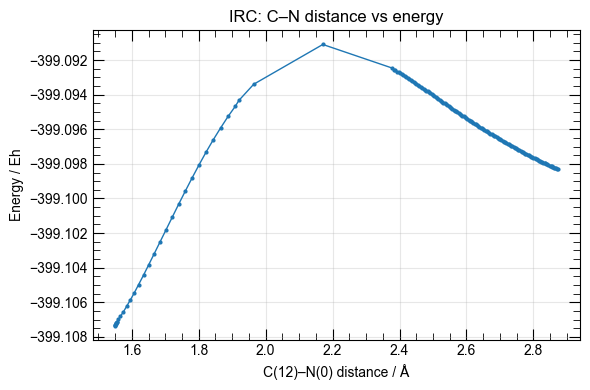

In [2]:
plt.figure(figsize=(6, 4))
plt.plot(dist_cn, energies_eh, marker="o", markersize=2, linewidth=1)
plt.xlabel("C(12)–N(0) distance / Å")
plt.ylabel("Energy / Eh")
plt.title("IRC: C–N distance vs energy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()